# Baseline DVFM Survival Prediction: Latent Marginalization vs No Latent

This notebook visualizes the fair baseline experiment in which **both models receive only test covariates \(x\)**.

The latent DVFM does not call its encoder on test subjects. Instead, it predicts

\[
\widehat S(t\mid x)=\frac{1}{M}\sum_{m=1}^{M}S(t\mid x,z_m),
\]

where the \(z_m\) values are sampled from an aggregate posterior estimated exclusively from training subjects. The no-latent model is separately trained as \(g_\theta(x)\).


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../outputs/support_clayton_frailty_tau05_baseline_latent_vs_no_latent")

results = json.loads((OUTPUT_DIR / "results.json").read_text(encoding="utf-8"))
latent_history = pd.read_csv(OUTPUT_DIR / "latent_training_history.csv")
no_latent_history = pd.read_csv(OUTPUT_DIR / "no_latent_training_history.csv")
predictions = pd.read_csv(
    OUTPUT_DIR / "baseline_latent_vs_no_latent_test_predictions.csv"
)
brier = pd.read_csv(OUTPUT_DIR / "baseline_oracle_brier_curves.csv")
latent_recovery = pd.read_csv(
    OUTPUT_DIR / "latent_recovery_test_diagnostic.csv"
)

comparison = results["baseline_survival_comparison"]
primary = comparison["all_test_primary"]

print(comparison["estimand"])
print("Latent test information:", comparison["test_information_latent_model"])
print("No-latent test information:", comparison["test_information_no_latent_model"])


baseline oracle survival prediction from covariates x only
Latent test information: x only
No-latent test information: x only


## Headline metrics

In [3]:
summary = pd.DataFrame({
    "Metric": ["Oracle CI", "Oracle IBS", "Oracle MAE"],
    "Latent marginalized": [
        primary["latent_oracle_ci"],
        primary["latent_oracle_ibs"],
        primary["latent_oracle_mae"],
    ],
    "No latent": [
        primary["no_latent_oracle_ci"],
        primary["no_latent_oracle_ibs"],
        primary["no_latent_oracle_mae"],
    ],
    "Delta latent - no latent": [
        primary["delta_oracle_ci"],
        primary["delta_oracle_ibs"],
        primary["delta_oracle_mae"],
    ],
})
summary


,Metric,Latent marginalized,No latent,Delta latent - no latent
0,Oracle CI,0.586117,0.607747,-0.021630
1,Oracle IBS,0.144115,0.140157,0.003959
2,Oracle MAE,inf,3345.536377,inf


c:\Users\au475271\miniconda3\envs\dvfm\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


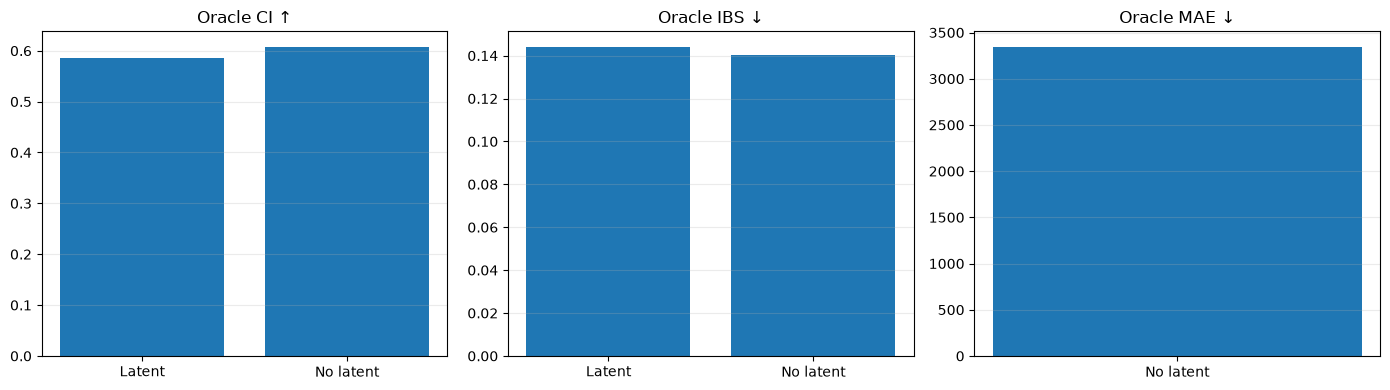

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, higher_better in zip(
    axes, ["Oracle CI", "Oracle IBS", "Oracle MAE"], [True, False, False]
):
    row = summary.loc[summary["Metric"] == metric].iloc[0]
    ax.bar(["Latent", "No latent"], [row["Latent marginalized"], row["No latent"]])
    ax.set_title(metric + (" ↑" if higher_better else " ↓"))
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## Matched training dynamics

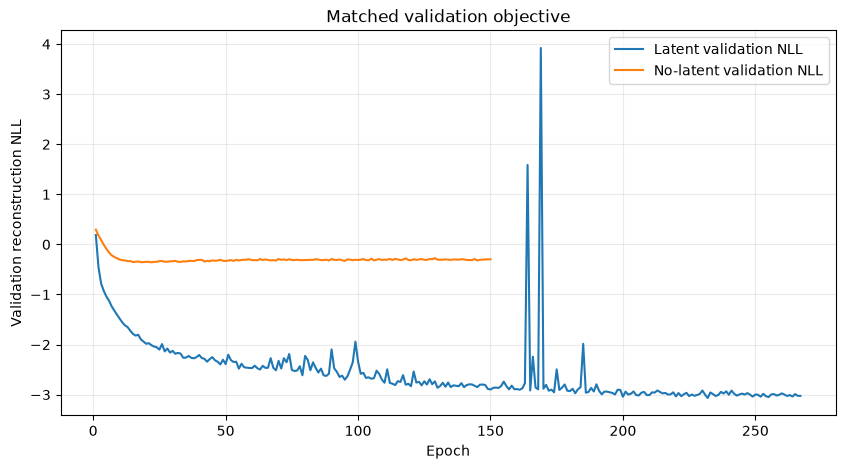

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    latent_history["epoch"],
    latent_history["validation_reconstruction_nll"],
    label="Latent validation NLL",
)
ax.plot(
    no_latent_history["epoch"],
    no_latent_history["validation_reconstruction_nll"],
    label="No-latent validation NLL",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation reconstruction NLL")
ax.set_title("Matched validation objective")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## Oracle Brier score over time

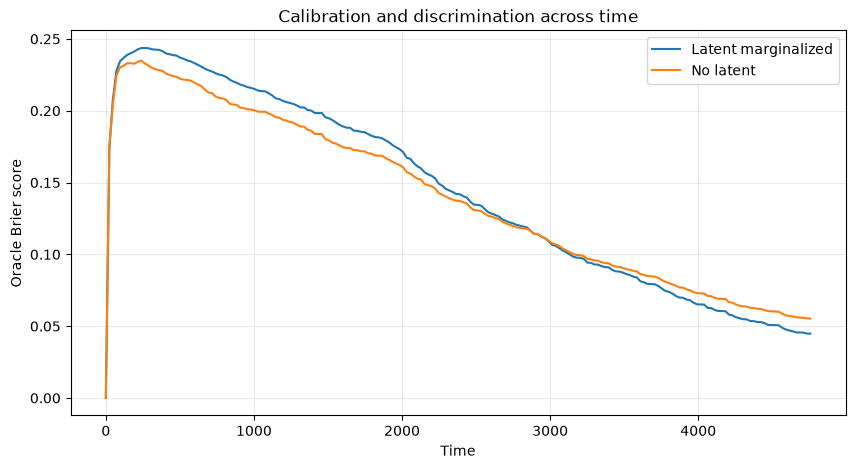

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(brier["time"], brier["latent_oracle_brier"], label="Latent marginalized")
ax.plot(brier["time"], brier["no_latent_oracle_brier"], label="No latent")
ax.set_xlabel("Time")
ax.set_ylabel("Oracle Brier score")
ax.set_title("Calibration and discrimination across time")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## Predicted versus true event time

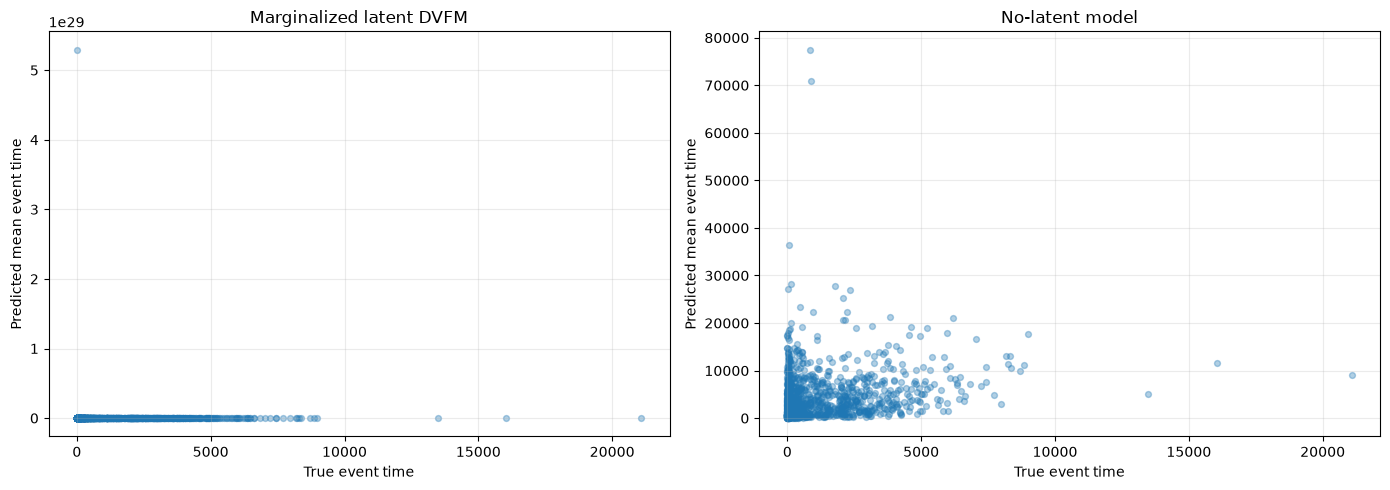

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    predictions["true_event_time"],
    predictions["latent_predicted_mean_event_time"],
    alpha=0.35,
    s=18,
)
axes[0].set_xlabel("True event time")
axes[0].set_ylabel("Predicted mean event time")
axes[0].set_title("Marginalized latent DVFM")
axes[0].grid(alpha=0.25)

axes[1].scatter(
    predictions["true_event_time"],
    predictions["no_latent_predicted_mean_event_time"],
    alpha=0.35,
    s=18,
)
axes[1].set_xlabel("True event time")
axes[1].set_ylabel("Predicted mean event time")
axes[1].set_title("No-latent model")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Subject-level error comparison

ValueError: supplied range of [-inf, 75983.9903087189] is not finite

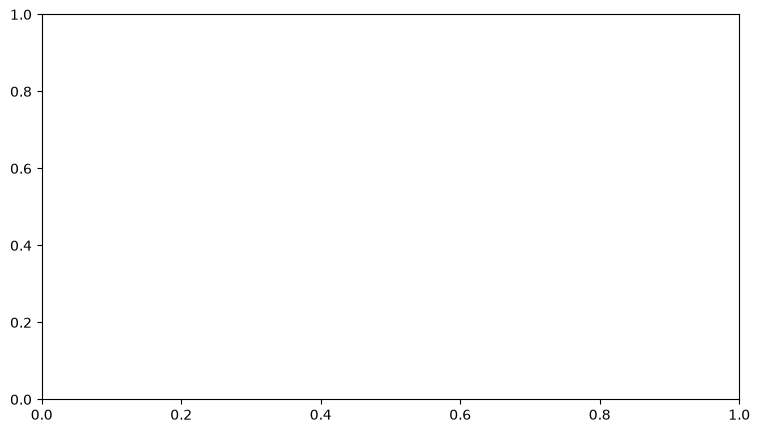

In [8]:
improvement = (
    predictions["no_latent_absolute_error"]
    - predictions["latent_absolute_error"]
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(improvement, bins=45, alpha=0.8)
ax.axvline(0.0, linestyle="--")
ax.set_xlabel("No-latent absolute error - latent absolute error")
ax.set_ylabel("Count")
ax.set_title("Positive values favor latent marginalization")
plt.show()

print(improvement.describe())
print(f"Fraction improved: {(improvement > 0).mean():.3f}")


## Frailty recovery remains a separate diagnostic

In [ ]:
latent_metrics = results["latent_model"]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    latent_recovery["true_z"],
    latent_recovery["learned_mu_aligned"],
    alpha=0.35,
    s=18,
)
ax.set_xlabel("True standardized log-frailty")
ax.set_ylabel("Aligned posterior mean")
ax.set_title(
    f"Test frailty recovery diagnostic: r={latent_metrics['pearson']:.3f}"
)
ax.grid(alpha=0.25)
plt.show()


## Interpretation

This experiment is a fair comparison for baseline prediction because test-time information is matched: both models receive only \(x\).

However, marginalizing over a population latent distribution removes subject-specific frailty information. Therefore, the latent model can outperform the no-latent model only if the latent architecture improves the learned population event distribution or represents useful heterogeneity after integration. A small or absent gain does not contradict strong subject-level frailty recovery when follow-up information is available; it means that the individual latent cannot be identified from \(x\) alone under the current architecture.
